轮数: 10, 平均损失值: 402.1443
轮数: 20, 平均损失值: 251.3173
轮数: 30, 平均损失值: 194.8487
轮数: 40, 平均损失值: 165.7151
轮数: 50, 平均损失值: 148.2745
轮数: 60, 平均损失值: 136.9469
轮数: 70, 平均损失值: 128.9122
轮数: 80, 平均损失值: 122.3769
轮数: 90, 平均损失值: 117.5560
轮数: 100, 平均损失值: 114.1137
------------------------------
训练完成！
模型参数，权重(w)：27.5549, 偏置(b): 14.0054
真实权重(coef): 27.4781, 真实偏置(bias): 14.5


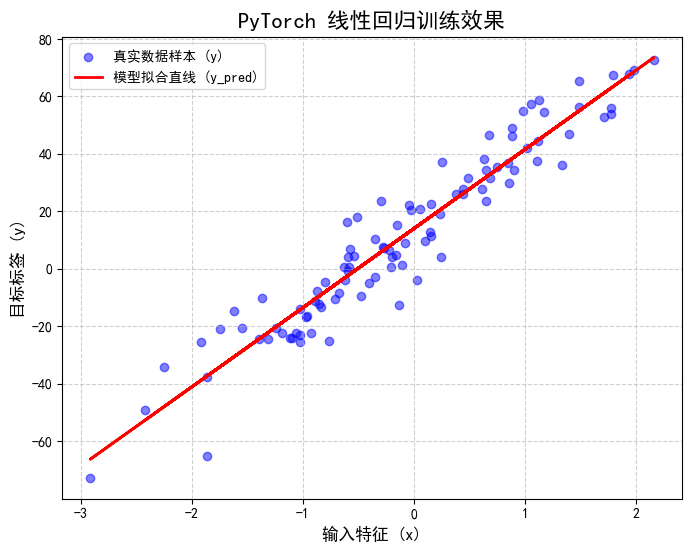

In [10]:
import torch
from torch.utils.data import TensorDataset   #数据集对象
from torch.utils.data import DataLoader      #数据加载器
from torch import nn
from torch import optim                      #此模块中有优化器函数
from sklearn.datasets import make_regression #创建线性回归模型数据集
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei'] #正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False   #正常显示负号

#定义函数创建线性回归
def create_dataset():
    x, y, coef = make_regression(
        n_samples=100,     #100个样本
        n_features=1,      #1个特征点
        noise=10,          #噪声，越大->样本点越散
        coef=True,         #是否返回系数
        bias=14.5,
        random_state=3     #随机种子
    )
    #将上述封装成张量
    x = torch.tensor(x, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32)
    return x, y, coef

#定义函数，模型训练
def train(x, y, coef):
    dataset = TensorDataset(x, y)
    # 修复点 1：首字母大写 DataLoader
    dataloader = DataLoader(dataset, batch_size=16, shuffle=True)
    
    model = nn.Linear(in_features=1, out_features=1)
    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01)

    # 修复点 2：将完整的训练循环缩进到 train 函数内部
    epochs, loss_list, total_loss, total_sample = 100, [], 0.0, 0
    
    for epoch in range(epochs):
        for train_x, train_y in dataloader:
            y_pred = model(train_x)
            loss = criterion(y_pred, train_y.reshape(-1, 1))
            
            total_loss += loss.item()
            total_sample += 1
            
            optimizer.zero_grad()
            loss.backward()   # 修复点 3：MSELoss 默认已经是求平均了，无需再 .sum()
            optimizer.step()
            
        # 记录每轮平均损失
        avg_loss = total_loss / total_sample
        loss_list.append(avg_loss)
        
        # 为了避免输出太长，我们可以每 10 轮打印一次进度
        if (epoch + 1) % 10 == 0:
            print(f'轮数: {epoch+1}, 平均损失值: {avg_loss:.4f}')

    # 打印最终训练结果
    print("-" * 30)
    print(f'训练完成！')
    print(f'模型参数，权重(w)：{model.weight.data.item():.4f}, 偏置(b): {model.bias.data.item():.4f}')
    print(f'真实权重(coef): {coef.item():.4f}, 真实偏置(bias): 14.5')
    #绘制图像
    # === 以下为新增的绘图代码 ===
    
    # 1. 准备数据：将 PyTorch 的张量 (Tensor) 转换回普通的 NumPy 数组，方便画图
    x_data = x.numpy()
    y_data = y.numpy()
    
    # 2. 计算拟合直线上的点：让训练好的模型对所有 x 进行一次预测
    # 注意：在 PyTorch 中，带有梯度的张量不能直接画图，必须先用 .detach() 剥离梯度计算图
    y_predict_line = model(x).detach().numpy()
    
    # 3. 开始用 matplotlib 画图
    plt.figure(figsize=(8, 6))  # 设置画布大小为 8x6
    
    # 绘制真实的数据散点（蓝色半透明圆点）
    plt.scatter(x_data, y_data, color='blue', alpha=0.5, label='真实数据样本 (y)')
    
    # 绘制模型学习到的线性回归直线（红色实线）
    plt.plot(x_data, y_predict_line, color='red', linewidth=2, label='模型拟合直线 (y_pred)')
    
    # 4. 添加图表装饰元素，让图表更专业
    plt.title('PyTorch 线性回归训练效果', fontsize=16)
    plt.xlabel('输入特征 (x)', fontsize=12)
    plt.ylabel('目标标签 (y)', fontsize=12)
    plt.legend(loc='upper left')  # 在左上角显示图例
    plt.grid(True, linestyle='--', alpha=0.6)  # 添加虚线网格背景
    
    # 显示最终生成的图像
    plt.show()

if __name__ == '__main__':
    # 修复点 4：接收数据，并传递给 train 函数执行
    data_x, data_y, real_coef = create_dataset()
    train(data_x, data_y, real_coef)
    
'''
=========================================
附：PyTorch 线性回归模型底层逻辑梳理
=========================================

这份代码展示了一个标准的深度学习训练流水线，核心可拆解为四个阶段：

第一阶段：准备“教材”（数据生成与加载）
- create_dataset()：构建虚拟实验环境，生成带随机误差的线性数据，并转化为张量 (Tensor)。
- DataLoader：如同“发牌员”，将数据打乱并切分成小批次 (Batch)，每次抽出 16 个样本喂给模型，提升训练效率。

第二阶段：构建“学生”与“评分标准”（模型、损失、优化器）
- 模型 (nn.Linear)：包含权重 w 和偏置 b，任务是接收输入 x，通过 y = wx + b 算出预测值。
- 损失函数 (MSELoss)：“评分标准”，负责对比预测值和真实标签，计算均方误差。误差越大，表现越差。
- 优化器 (SGD)：“指导老师”，根据误差大小和设定的学习率 (lr)，负责具体去修改模型里的参数。

第三阶段：核心学习过程（训练循环）
嵌套双层 for 循环执行经典的“五步走”战略：
- 外层循环：决定模型把整本教材完整学习多少遍 (100个 epoch)。
- 内层循环：按批次学习。
  1. 前向传播：y_pred = model(train_x)，模型给出预测结果。
  2. 计算损失：loss = criterion(...)，评估预测错得有多离谱。
  3. 梯度清零：optimizer.zero_grad()，清空上一次计算留下的梯度痕迹。
  4. 反向传播：loss.backward()，核心微积分操作，算出误差对各个参数的责任（梯度）。
  5. 参数更新：optimizer.step()，优化器根据梯度，正式修改 w 和 b。

第四阶段：复盘与可视化（评估）
- 记录日志：每个 epoch 结束后记录平均损失，相当于记录模型的“考试平均分”。
- 绘图展示：利用 matplotlib 绘制损失下降曲线，直观验证模型在不断纠正自身错误的过程。
'''